# Analyse der 200ms Simulationsergebnisse

Vollständige Analyse der Parameter Sweep Ergebnisse mit **200ms Simulationszeit** (korrigiert).

**Datensatz:** `parameter_sweep_DA_20260227_194745/`

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob

# Seaborn-Stil
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

## 1. Daten laden (200ms Simulationen)

In [37]:
# Pfad zu den 200ms Daten
data_dir = Path('parameter_sweep_DA_20260227_194745')
csv_file = data_dir / 'all_results_summary.csv'

# Daten laden (roh)
df_raw = pd.read_csv(csv_file)

# Setting-Key aufbauen (für Datei-Konsistenzcheck)
df_raw['setting_key'] = (
    'F' + df_raw['Force_Target_N'].astype(int).astype(str).str.zfill(2)
    + '_ratio' + df_raw['Aspect_Ratio_b_a'].map(lambda x: f'{x:.4f}')
    + '_Vol' + df_raw['Volume_cm3'].map(lambda x: f'{x:.1f}')
    + '_Am' + df_raw['Am'].astype(int).astype(str)
    + '_rho' + df_raw['Rho'].map(lambda x: f'{x:.3f}')
)

# Prüfe, ob zu jedem Summary-Eintrag eine Kontraktions-Zeitreihe vorhanden ist
df_raw['has_direct_file'] = df_raw['setting_key'].map(lambda k: (data_dir / k / 'muscle_length_contraction.csv').exists())
df_raw['has_archived_file'] = df_raw['setting_key'].map(lambda k: (data_dir / 'archived_results' / k / 'muscle_length_contraction.csv').exists())
df_raw['has_any_timeseries_file'] = df_raw['has_direct_file'] | df_raw['has_archived_file']

# Gefilterter Datensatz für alle weiteren Auswertungen
df = df_raw[df_raw['has_any_timeseries_file']].copy()

# Surface Area berechnen
df['Surface_Area_calc'] = df['muscle_a_cm'] ** 2
REFERENCE_AREA = 12.033883  # cm²

print(f"✓ Rohdaten geladen: {len(df_raw)} Simulationen")
print(f"✓ Verwendete gültige Simulationen (mit Zeitreihe): {len(df)}")
print(f"⚠️ Entfernte Einträge ohne Zeitreihen-Datei: {len(df_raw) - len(df)}")

if len(df_raw) > len(df):
    removed = df_raw[~df_raw['has_any_timeseries_file']].copy()
    print("\nHäufigste entfernte Gruppen (ratio, vol):")
    print(removed.groupby(['Aspect_Ratio_b_a', 'Volume_cm3']).size().sort_values(ascending=False).head(10))

print(f"\nDatensatz erstellt: {df['Completed_Date'].iloc[0]}")
print(f"\nSpalten: {list(df.columns)}")
print(f"\n{'='*80}")
print("Parameter-Ranges (gefiltert):")
print(f"{'='*80}")
print(f"Force_Target_N: {sorted(df['Force_Target_N'].unique())}")
print(f"Aspect_Ratio_b_a: {sorted(df['Aspect_Ratio_b_a'].unique())}")
print(f"Volume_cm3: {sorted(df['Volume_cm3'].unique())}")
print(f"Am: {sorted(df['Am'].unique())}")
print(f"Rho: {sorted(df['Rho'].unique())}")

df.head()

✓ Rohdaten geladen: 3840 Simulationen
✓ Verwendete gültige Simulationen (mit Zeitreihe): 280
⚠️ Entfernte Einträge ohne Zeitreihen-Datei: 3560

Häufigste entfernte Gruppen (ratio, vol):
Aspect_Ratio_b_a  Volume_cm3
10.1000           738.0         192
                  573.5         192
9.0267            738.0         192
                  691.2         192
                  573.5         192
                  455.9         192
6.8800            455.9         192
7.9533            738.0         192
                  691.2         192
                  573.5         192
dtype: int64

Datensatz erstellt: Fr 27. Feb 20:43:10 CET 2026

Spalten: ['Force_Target_N', 'Force_Actual_N', 'Stress_N_per_cm2', 'Aspect_Ratio_b_a', 'muscle_b_cm', 'muscle_a_cm', 'Volume_cm3', 'Am', 'Rho', 'Initial_Length_cm', 'Prestretch_Final_Length_cm', 'Prestretch_Elongation_cm', 'Prestretch_Strain', 'Max_Length_cm', 'Min_Length_cm', 'ROM_cm', 'Contraction_Strain', 'Completed_Date', 'setting_key', 'has_direct_file', 

,Force_Target_N,Force_Actual_N,Stress_N_per_cm2,Aspect_Ratio_b_a,muscle_b_cm,muscle_a_cm,Volume_cm3,Am,Rho,Initial_Length_cm,...,Max_Length_cm,Min_Length_cm,ROM_cm,Contraction_Strain,Completed_Date,setting_key,has_direct_file,has_archived_file,has_any_timeseries_file,Surface_Area_calc
0,3,3.874861,0.249296,6.88,27.124317,3.942488,421.6,450,10.534,27.124317,...,27.769125,25.077824,2.691300,0.099220,Fr 27. Feb 20:43:10 CET 2026,F03_ratio6.8800_Vol421.6_Am450_rho10.534,False,True,True,15.543212
1,3,3.874861,0.249296,6.88,27.124317,3.942488,421.6,450,10.493,27.124317,...,27.769125,25.078110,2.691015,0.099210,Fr 27. Feb 20:43:11 CET 2026,F03_ratio6.8800_Vol421.6_Am450_rho10.493,False,True,True,15.543212
2,6,7.749723,0.498592,6.88,27.124317,3.942488,421.6,450,10.534,27.124317,...,28.477810,25.538082,2.939728,0.108379,Fr 27. Feb 20:43:13 CET 2026,F06_ratio6.8800_Vol421.6_Am450_rho10.534,False,True,True,15.543212
3,0,0.000000,0.000000,6.88,27.124317,3.942488,421.6,450,10.493,27.124317,...,27.124317,24.646892,2.477426,0.091335,Fr 27. Feb 20:43:13 CET 2026,F00_ratio6.8800_Vol421.6_Am450_rho10.493,False,True,True,15.543212
5,12,15.499447,0.997184,6.88,27.124317,3.942488,421.6,450,10.493,27.124317,...,30.133619,26.556779,3.576840,0.131868,Fr 27. Feb 20:43:16 CET 2026,F12_ratio6.8800_Vol421.6_Am450_rho10.493,False,True,True,15.543212


## 2. ROM vs Force - Hauptergebnis! 🎯

**Erwartung:** ROM sollte mit Force steigen (oder parabolisch verlaufen).

/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_65005/2766390961.py:78: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_65005/2766390961.py:79: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig(data_dir / 'rom_analysis_200ms.png', dpi=300, bbox_inches='tight')
/Users/canis/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


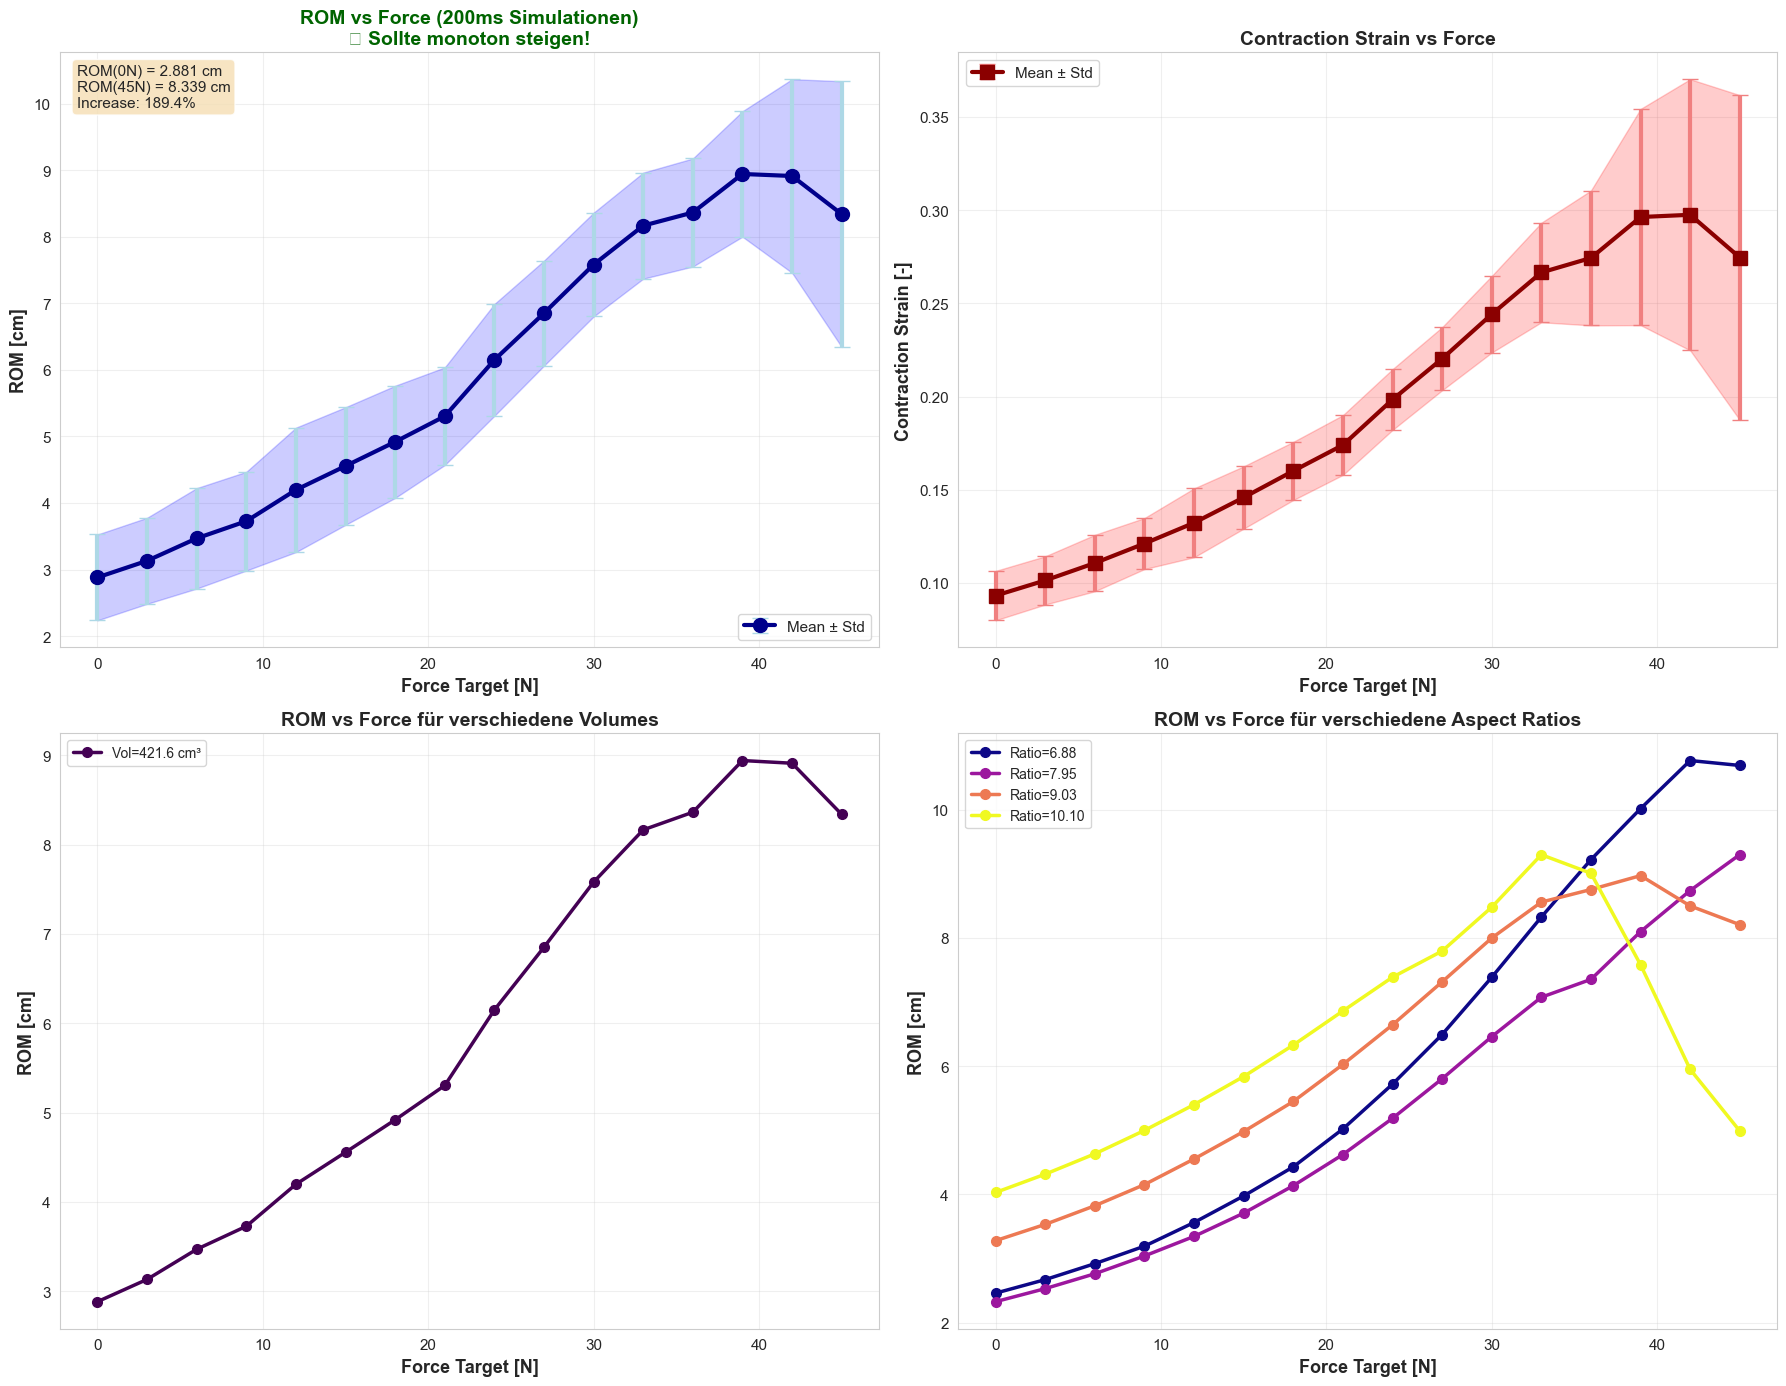


ROM STATISTIK (200ms Simulationen):
                  ROM_cm                                     
                    mean       std count       min        max
Force_Target_N                                               
0               2.881274  0.644670    19  2.316670   4.033317
3               3.130950  0.646367    22  2.517447   4.320089
6               3.468192  0.754532    19  2.748937   4.637165
9               3.726038  0.741912    18  3.018762   5.006669
12              4.196306  0.934671    13  3.331137   5.408377
15              4.554783  0.883351    13  3.695453   5.847103
18              4.918180  0.842657    17  4.118976   6.350267
21              5.302867  0.733659    18  4.604183   6.860626
24              6.148973  0.839688    21  5.167175   7.402031
27              6.851460  0.789206    16  5.787707   7.831335
30              7.580620  0.779555    16  6.440637   8.498068
33              8.165862  0.796671    20  7.054931   9.323982
36              8.363304  0.81159

In [38]:
# ROM vs Force - Hauptplot
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. ROM vs Force_Target (Mittelwert ± Std)
ax = axes[0, 0]
rom_by_force = df.groupby('Force_Target_N').agg({
    'ROM_cm': ['mean', 'std', 'count', 'min', 'max']
})
forces = rom_by_force.index
rom_mean = rom_by_force['ROM_cm']['mean']
rom_std = rom_by_force['ROM_cm']['std']

ax.errorbar(forces, rom_mean, yerr=rom_std, fmt='o-', linewidth=3, markersize=10, 
            capsize=6, color='darkblue', ecolor='lightblue', label='Mean ± Std')
ax.fill_between(forces, rom_mean - rom_std, rom_mean + rom_std, alpha=0.2, color='blue')
ax.set_xlabel('Force Target [N]', fontsize=13, fontweight='bold')
ax.set_ylabel('ROM [cm]', fontsize=13, fontweight='bold')
ax.set_title('ROM vs Force (200ms Simulationen)\n✓ Sollte monoton steigen!', 
             fontsize=14, fontweight='bold', color='darkgreen')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Text Annotations
rom_0 = rom_mean[0]
rom_45 = rom_mean[45] if 45 in rom_mean.index else rom_mean[-1]
rom_increase = ((rom_45 - rom_0) / rom_0) * 100
ax.text(0.02, 0.98, f'ROM(0N) = {rom_0:.3f} cm\nROM(45N) = {rom_45:.3f} cm\nIncrease: {rom_increase:.1f}%',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 2. Contraction Strain vs Force
ax = axes[0, 1]
strain_by_force = df.groupby('Force_Target_N').agg({
    'Contraction_Strain': ['mean', 'std']
})
strain_mean = strain_by_force['Contraction_Strain']['mean']
strain_std = strain_by_force['Contraction_Strain']['std']

ax.errorbar(forces, strain_mean, yerr=strain_std, fmt='s-', linewidth=3, markersize=10,
            capsize=6, color='darkred', ecolor='lightcoral', label='Mean ± Std')
ax.fill_between(forces, strain_mean - strain_std, strain_mean + strain_std, alpha=0.2, color='red')
ax.set_xlabel('Force Target [N]', fontsize=13, fontweight='bold')
ax.set_ylabel('Contraction Strain [-]', fontsize=13, fontweight='bold')
ax.set_title('Contraction Strain vs Force', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# 3. ROM für verschiedene Volumes
ax = axes[1, 0]
volumes = sorted(df['Volume_cm3'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(volumes)))
for vol, color in zip(volumes, colors):
    subset = df[df['Volume_cm3'] == vol]
    subset_grouped = subset.groupby('Force_Target_N')[['ROM_cm']].mean()
    ax.plot(subset_grouped.index, subset_grouped['ROM_cm'], 
            'o-', label=f'Vol={vol:.1f} cm³', linewidth=2.5, markersize=7, color=color)
ax.set_xlabel('Force Target [N]', fontsize=13, fontweight='bold')
ax.set_ylabel('ROM [cm]', fontsize=13, fontweight='bold')
ax.set_title('ROM vs Force für verschiedene Volumes', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 4. ROM für verschiedene Aspect Ratios
ax = axes[1, 1]
ratios = sorted(df['Aspect_Ratio_b_a'].unique())
colors = plt.cm.plasma(np.linspace(0, 1, len(ratios)))
for ratio, color in zip(ratios, colors):
    subset = df[df['Aspect_Ratio_b_a'] == ratio]
    subset_grouped = subset.groupby('Force_Target_N')[['ROM_cm']].mean()
    ax.plot(subset_grouped.index, subset_grouped['ROM_cm'], 
            'o-', label=f'Ratio={ratio:.2f}', linewidth=2.5, markersize=7, color=color)
ax.set_xlabel('Force Target [N]', fontsize=13, fontweight='bold')
ax.set_ylabel('ROM [cm]', fontsize=13, fontweight='bold')
ax.set_title('ROM vs Force für verschiedene Aspect Ratios', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_dir / 'rom_analysis_200ms.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistik ausgeben
print("\n" + "="*80)
print("ROM STATISTIK (200ms Simulationen):")
print("="*80)
print(rom_by_force.round(6))

## 4. Zeitverlauf: Muskellänge während Kontraktion

Laden und plotten der `muscle_length_contraction.csv` Dateien für verschiedene Parameter-Kombinationen.

In [28]:
# Funktion zum Laden einer Zeitreihe
def load_contraction_timeseries(sim_dir):
    """Lädt muscle_length_contraction.csv aus einem Simulationsverzeichnis."""
    csv_path = sim_dir / 'muscle_length_contraction.csv'
    if not csv_path.exists():
        # Try in archived_results
        csv_path = data_dir / 'archived_results' / sim_dir.name / 'muscle_length_contraction.csv'
    
    if csv_path.exists():
        # Daten sind komma-separiert in einer Zeile
        with open(csv_path, 'r') as f:
            data_str = f.read().strip()
        
        # Split by comma und convert to float
        lengths = [float(x) for x in data_str.split(',') if x.strip()]
        
        # Zeitpunkte (0.1 ms Schritte)
        dt = 0.1  # ms
        times = np.arange(len(lengths)) * dt
        
        return times, np.array(lengths)
    return None, None

# Test: Lade ein paar Beispiele
print("Testing time series loading...")
test_dir = data_dir / 'F00_ratio6.8800_Vol421.6_Am450_rho10.493'
if test_dir.exists():
    times, lengths = load_contraction_timeseries(test_dir)
    if times is not None:
        print(f"✓ Loaded {len(lengths)} time points")
        print(f"  Time range: {times[0]:.1f} - {times[-1]:.1f} ms")
        print(f"  Length range: {lengths.min():.3f} - {lengths.max():.3f} cm")
        print(f"  ROM: {lengths.max() - lengths.min():.3f} cm")
    else:
        print("⚠️ Could not load time series")
else:
    print(f"⚠️ Test directory not found: {test_dir}")

Testing time series loading...
⚠️ Test directory not found: parameter_sweep_DA_20260227_194745/F00_ratio6.8800_Vol421.6_Am450_rho10.493


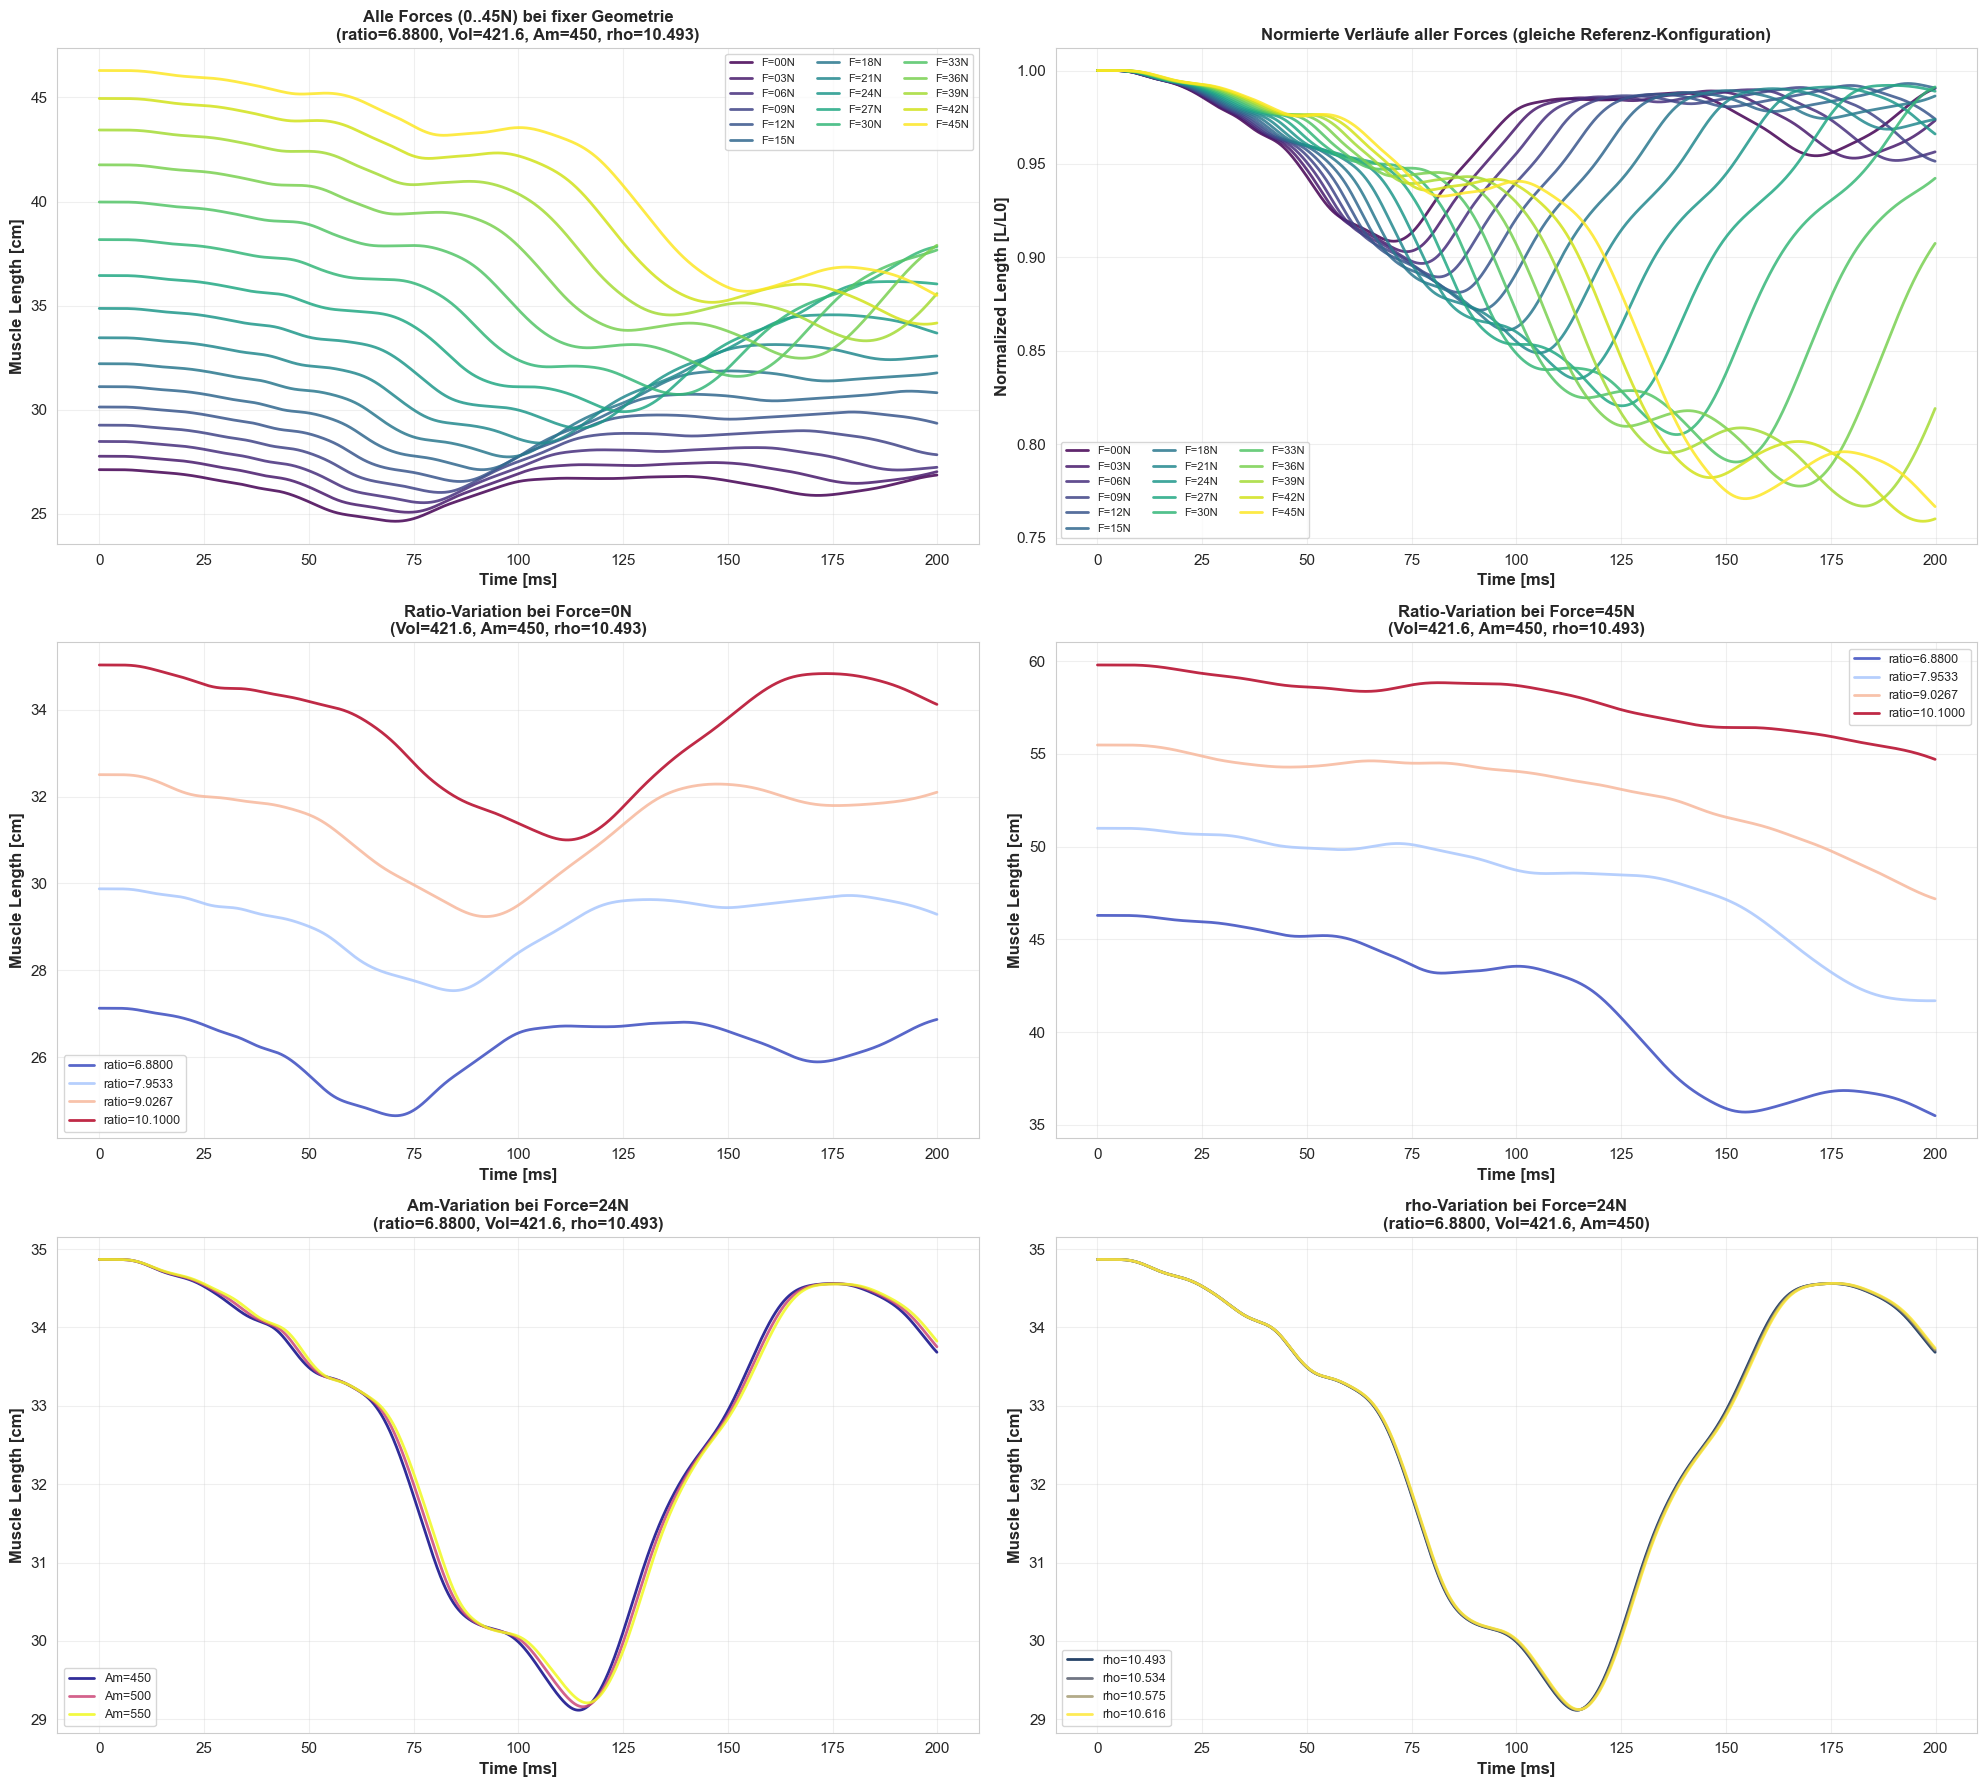


ERWEITERTE PLOT-AUSWAHL ERSTELLT
Forces (alle): [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45]
Ratio-Werte: [6.88, 7.9533, 9.0267, 10.1]
Volume-Werte: [421.6, 455.9, 573.5, 691.2, 738.0]
Am-Werte: [450, 500, 550]
rho-Werte: [10.493, 10.534, 10.575, 10.616]
Gespeichert als: parameter_sweep_DA_20260227_194745/contraction_timeseries_extended_selection.png


In [29]:
# Erweiterte Plot-Auswahl: Zeitverläufe mit mehreren Force-Stufen und Parameter-Variationen
fig, axes = plt.subplots(3, 2, figsize=(20, 18))

# Verfügbare Parameterwerte
force_levels = sorted([int(x) for x in df['Force_Target_N'].unique()])
ratio_levels = sorted([float(x) for x in df['Aspect_Ratio_b_a'].unique()])
volume_levels = sorted([float(x) for x in df['Volume_cm3'].unique()])
am_levels = sorted([int(x) for x in df['Am'].unique()])
rho_levels = sorted([float(x) for x in df['Rho'].unique()])

# Repräsentative Force-Stufen
f_low = force_levels[0]
f_mid = force_levels[len(force_levels) // 2]
f_high = force_levels[-1]
selected_forces = [f_low, f_mid, f_high]

# Referenzwerte
ref_ratio = ratio_levels[0]
ref_vol = volume_levels[0]
ref_am = am_levels[0]
ref_rho = rho_levels[0]

# Hilfsfunktion: robustes Laden mit Parameter-Kombi
def load_by_params(force, ratio, vol, am, rho):
    dir_name = f"F{int(force):02d}_ratio{ratio:.4f}_Vol{vol:.1f}_Am{int(am)}_rho{rho:.3f}"
    sim_dir = data_dir / dir_name
    times, lengths = load_contraction_timeseries(sim_dir)
    return dir_name, times, lengths

# ---------------------------------------------------------------
# Plot 1 (oben links): Alle Forces für eine Referenz-Konfiguration
# ---------------------------------------------------------------
ax = axes[0, 0]
colors_force = plt.cm.viridis(np.linspace(0, 1, len(force_levels)))
for f, c in zip(force_levels, colors_force):
    _, times, lengths = load_by_params(f, ref_ratio, ref_vol, ref_am, ref_rho)
    if times is not None:
        ax.plot(times, lengths, linewidth=2, color=c, alpha=0.85, label=f'F={f:02d}N')

ax.set_xlabel('Time [ms]', fontsize=12, fontweight='bold')
ax.set_ylabel('Muscle Length [cm]', fontsize=12, fontweight='bold')
ax.set_title(
    f'Alle Forces (0..45N) bei fixer Geometrie\n(ratio={ref_ratio:.4f}, Vol={ref_vol:.1f}, Am={ref_am}, rho={ref_rho:.3f})',
    fontsize=12,
    fontweight='bold'
)
ax.legend(fontsize=8, ncol=3, loc='best')
ax.grid(True, alpha=0.3)

# ---------------------------------------------------------------
# Plot 2 (oben rechts): Normierte Verläufe aller Forces
# ---------------------------------------------------------------
ax = axes[0, 1]
for f, c in zip(force_levels, colors_force):
    _, times, lengths = load_by_params(f, ref_ratio, ref_vol, ref_am, ref_rho)
    if times is not None and lengths[0] != 0:
        ax.plot(times, lengths / lengths[0], linewidth=2, color=c, alpha=0.85, label=f'F={f:02d}N')

ax.set_xlabel('Time [ms]', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalized Length [L/L0]', fontsize=12, fontweight='bold')
ax.set_title('Normierte Verläufe aller Forces (gleiche Referenz-Konfiguration)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='best')
ax.grid(True, alpha=0.3)

# ---------------------------------------------------------------
# Plot 3/4 (Mitte): Ratio-Variation bei niedriger und hoher Force
# ---------------------------------------------------------------
for i, force in enumerate([f_low, f_high]):
    ax = axes[1, i]
    colors_ratio = plt.cm.coolwarm(np.linspace(0, 1, len(ratio_levels)))

    for ratio, c in zip(ratio_levels, colors_ratio):
        _, times, lengths = load_by_params(force, ratio, ref_vol, ref_am, ref_rho)
        if times is not None:
            ax.plot(times, lengths, linewidth=2, color=c, alpha=0.85, label=f'ratio={ratio:.4f}')

    ax.set_xlabel('Time [ms]', fontsize=12, fontweight='bold')
    ax.set_ylabel('Muscle Length [cm]', fontsize=12, fontweight='bold')
    ax.set_title(
        f'Ratio-Variation bei Force={force}N\n(Vol={ref_vol:.1f}, Am={ref_am}, rho={ref_rho:.3f})',
        fontsize=12,
        fontweight='bold'
    )
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

# ---------------------------------------------------------------
# Plot 5/6 (unten): Am-Variation bei mittlerer Force + rho-Variation bei mittlerer Force
# ---------------------------------------------------------------
# Plot 5: Am-Variation
ax = axes[2, 0]
colors_am = plt.cm.plasma(np.linspace(0, 1, len(am_levels)))
for am, c in zip(am_levels, colors_am):
    _, times, lengths = load_by_params(f_mid, ref_ratio, ref_vol, am, ref_rho)
    if times is not None:
        ax.plot(times, lengths, linewidth=2, color=c, alpha=0.85, label=f'Am={am}')

ax.set_xlabel('Time [ms]', fontsize=12, fontweight='bold')
ax.set_ylabel('Muscle Length [cm]', fontsize=12, fontweight='bold')
ax.set_title(
    f'Am-Variation bei Force={f_mid}N\n(ratio={ref_ratio:.4f}, Vol={ref_vol:.1f}, rho={ref_rho:.3f})',
    fontsize=12,
    fontweight='bold'
)
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)

# Plot 6: rho-Variation
ax = axes[2, 1]
colors_rho = plt.cm.cividis(np.linspace(0, 1, len(rho_levels)))
for rho, c in zip(rho_levels, colors_rho):
    _, times, lengths = load_by_params(f_mid, ref_ratio, ref_vol, ref_am, rho)
    if times is not None:
        ax.plot(times, lengths, linewidth=2, color=c, alpha=0.85, label=f'rho={rho:.3f}')

ax.set_xlabel('Time [ms]', fontsize=12, fontweight='bold')
ax.set_ylabel('Muscle Length [cm]', fontsize=12, fontweight='bold')
ax.set_title(
    f'rho-Variation bei Force={f_mid}N\n(ratio={ref_ratio:.4f}, Vol={ref_vol:.1f}, Am={ref_am})',
    fontsize=12,
    fontweight='bold'
)
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_dir / 'contraction_timeseries_extended_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n' + '='*90)
print('ERWEITERTE PLOT-AUSWAHL ERSTELLT')
print('='*90)
print(f'Forces (alle): {force_levels}')
print(f'Ratio-Werte: {ratio_levels}')
print(f'Volume-Werte: {volume_levels}')
print(f'Am-Werte: {am_levels}')
print(f'rho-Werte: {rho_levels}')
print(f'Gespeichert als: {data_dir / "contraction_timeseries_extended_selection.png"}')
print('='*90)

## 5. Detaillierte Analyse einzelner Zeitverläufe

Zeige Details wie Prestretch-Phase, Peak, und Relaxation.

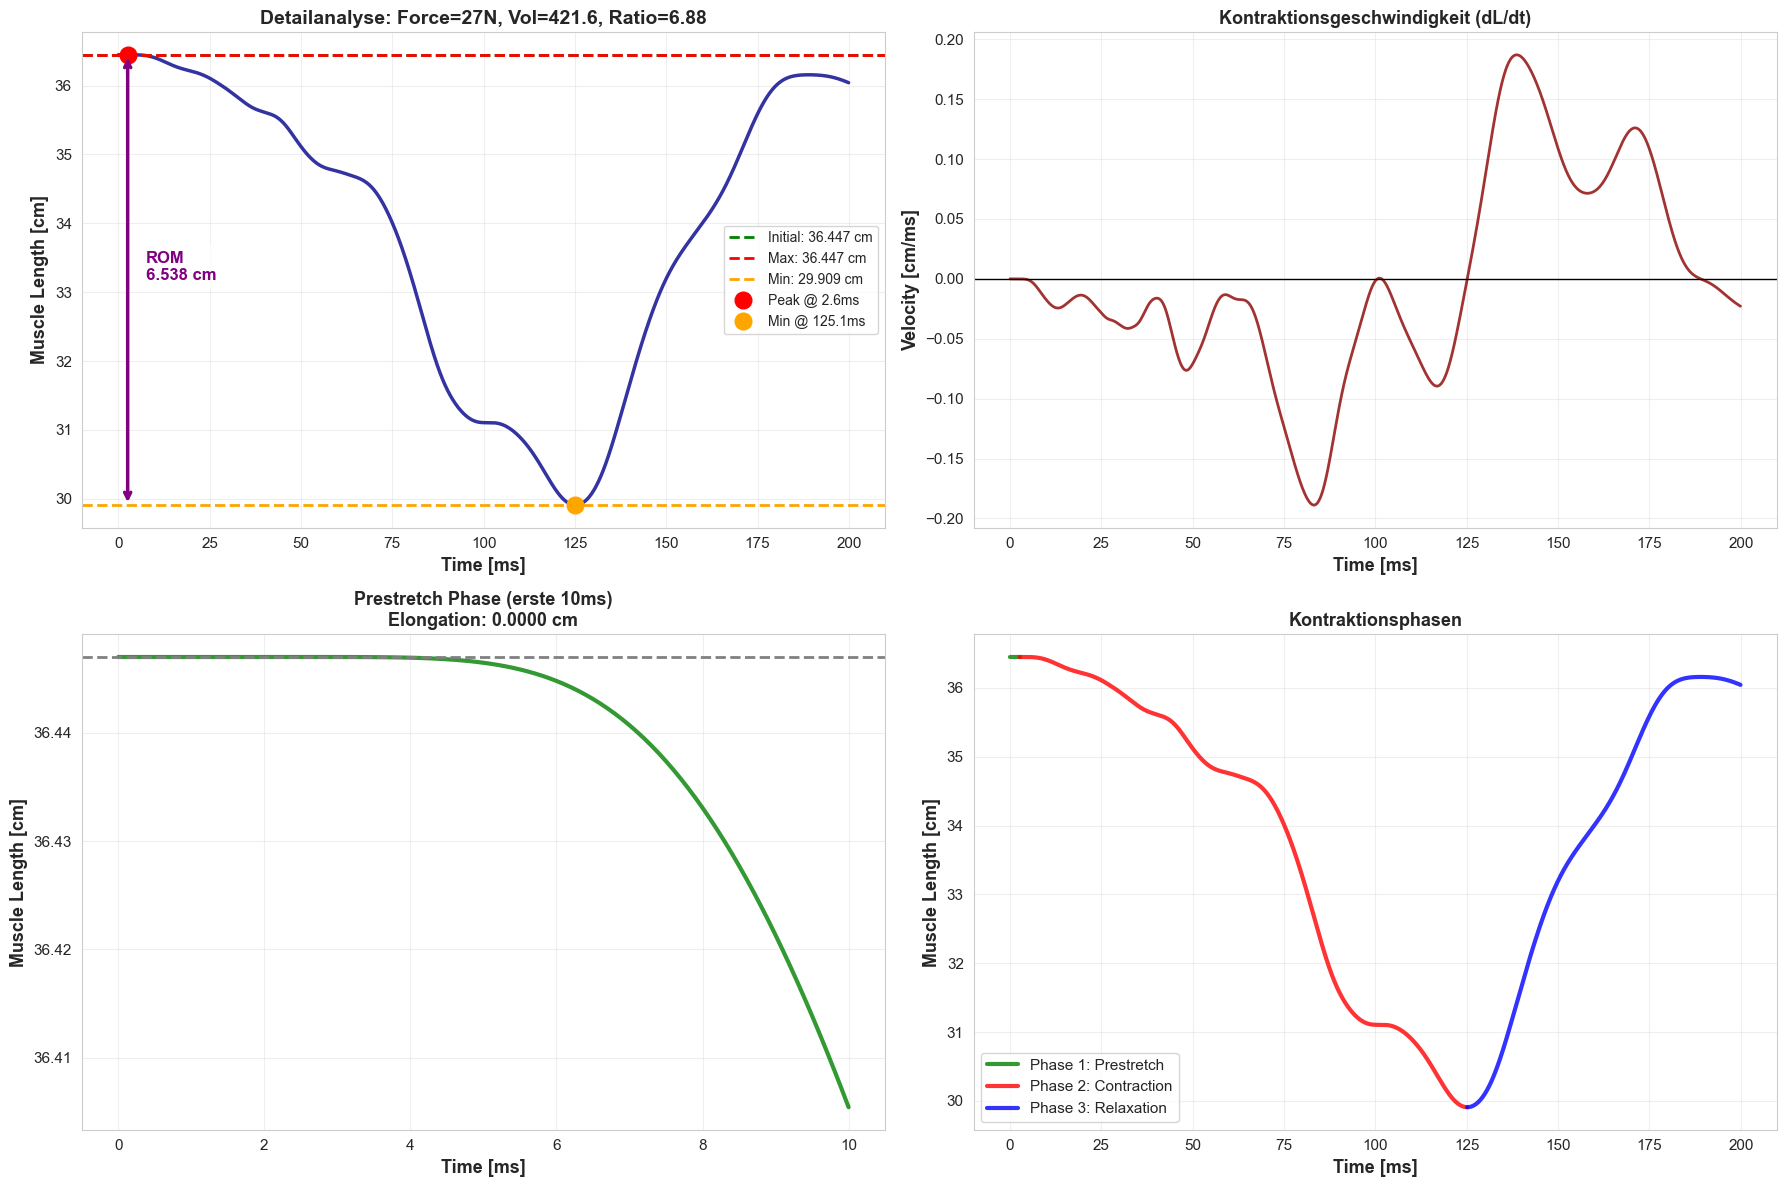


DETAILANALYSE: Force=27N
Initial Length:         36.446993 cm
Max Length (Prestretch):36.446994 cm @ 2.6 ms
Min Length (Contracted):29.909346 cm @ 125.1 ms
Prestretch Elongation:  0.000001 cm
ROM (Range of Motion):  6.537648 cm
Contraction Duration:   122.5 ms
Max Velocity:           0.187006 cm/ms
Min Velocity:           -0.188831 cm/ms


In [30]:
# Detailanalyse für eine spezifische Konfiguration
force_detail = 27
dir_name = f"F{int(force_detail):02d}_ratio{fixed_ratio:.4f}_Vol{fixed_vol}_Am{int(fixed_am)}_rho{fixed_rho}"
sim_dir = data_dir / dir_name

times, lengths = load_contraction_timeseries(sim_dir)

if times is not None:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Kompletter Zeitverlauf mit Markierungen
    ax = axes[0, 0]
    ax.plot(times, lengths, linewidth=2.5, color='darkblue', alpha=0.8)
    
    # Markiere wichtige Punkte
    initial_length = lengths[0]
    max_length = lengths.max()
    min_length = lengths.min()
    max_idx = lengths.argmax()
    min_idx = lengths.argmin()
    
    ax.axhline(y=initial_length, color='green', linestyle='--', linewidth=2, label=f'Initial: {initial_length:.3f} cm')
    ax.axhline(y=max_length, color='red', linestyle='--', linewidth=2, label=f'Max: {max_length:.3f} cm')
    ax.axhline(y=min_length, color='orange', linestyle='--', linewidth=2, label=f'Min: {min_length:.3f} cm')
    
    ax.plot(times[max_idx], max_length, 'ro', markersize=12, label=f'Peak @ {times[max_idx]:.1f}ms')
    ax.plot(times[min_idx], min_length, 'o', color='orange', markersize=12, label=f'Min @ {times[min_idx]:.1f}ms')
    
    # ROM Annotation
    rom = max_length - min_length
    ax.annotate('', xy=(times[max_idx], min_length), xytext=(times[max_idx], max_length),
                arrowprops=dict(arrowstyle='<->', lw=2.5, color='purple'))
    ax.text(times[max_idx] + 5, (max_length + min_length) / 2, f'ROM\n{rom:.3f} cm',
            fontsize=12, fontweight='bold', color='purple',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Time [ms]', fontsize=13, fontweight='bold')
    ax.set_ylabel('Muscle Length [cm]', fontsize=13, fontweight='bold')
    ax.set_title(f'Detailanalyse: Force={force_detail}N, Vol={fixed_vol}, Ratio={fixed_ratio}',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)
    
    # 2. Geschwindigkeit (1. Ableitung)
    ax = axes[0, 1]
    velocity = np.gradient(lengths, times)
    ax.plot(times, velocity, linewidth=2, color='darkred', alpha=0.8)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Time [ms]', fontsize=13, fontweight='bold')
    ax.set_ylabel('Velocity [cm/ms]', fontsize=13, fontweight='bold')
    ax.set_title('Kontraktionsgeschwindigkeit (dL/dt)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 3. Prestretch Phase (erste 10ms)
    ax = axes[1, 0]
    prestretch_mask = times <= 10
    ax.plot(times[prestretch_mask], lengths[prestretch_mask], linewidth=3, color='green', alpha=0.8)
    ax.axhline(y=initial_length, color='gray', linestyle='--', linewidth=2)
    prestretch_elong = max(lengths[prestretch_mask]) - initial_length
    ax.set_xlabel('Time [ms]', fontsize=13, fontweight='bold')
    ax.set_ylabel('Muscle Length [cm]', fontsize=13, fontweight='bold')
    ax.set_title(f'Prestretch Phase (erste 10ms)\nElongation: {prestretch_elong:.4f} cm',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 4. Phasen-Diagramm
    ax = axes[1, 1]
    
    # Identifiziere Phasen
    contraction_start = max_idx
    
    # Phase 1: Prestretch (0 bis peak)
    phase1_mask = times <= times[max_idx]
    ax.plot(times[phase1_mask], lengths[phase1_mask], linewidth=3, color='green', 
            label='Phase 1: Prestretch', alpha=0.8)
    
    # Phase 2: Contraction (peak bis min)
    phase2_mask = (times >= times[max_idx]) & (times <= times[min_idx])
    ax.plot(times[phase2_mask], lengths[phase2_mask], linewidth=3, color='red',
            label='Phase 2: Contraction', alpha=0.8)
    
    # Phase 3: Relaxation (min bis ende)
    phase3_mask = times >= times[min_idx]
    ax.plot(times[phase3_mask], lengths[phase3_mask], linewidth=3, color='blue',
            label='Phase 3: Relaxation', alpha=0.8)
    
    ax.set_xlabel('Time [ms]', fontsize=13, fontweight='bold')
    ax.set_ylabel('Muscle Length [cm]', fontsize=13, fontweight='bold')
    ax.set_title('Kontraktionsphasen', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(data_dir / f'detailed_analysis_F{force_detail}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Statistik ausgeben
    print("\n" + "="*80)
    print(f"DETAILANALYSE: Force={force_detail}N")
    print("="*80)
    print(f"Initial Length:         {initial_length:.6f} cm")
    print(f"Max Length (Prestretch):{max_length:.6f} cm @ {times[max_idx]:.1f} ms")
    print(f"Min Length (Contracted):{min_length:.6f} cm @ {times[min_idx]:.1f} ms")
    print(f"Prestretch Elongation:  {max_length - initial_length:.6f} cm")
    print(f"ROM (Range of Motion):  {rom:.6f} cm")
    print(f"Contraction Duration:   {times[min_idx] - times[max_idx]:.1f} ms")
    print(f"Max Velocity:           {velocity.max():.6f} cm/ms")
    print(f"Min Velocity:           {velocity.min():.6f} cm/ms")
    print("="*80)
else:
    print(f"⚠️ Could not load data for {dir_name}")

## 6. Stress-Konsistenz und Force-Skalierung

/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_65005/640993986.py:40: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_65005/640993986.py:41: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig(data_dir / 'stress_consistency.png', dpi=300, bbox_inches='tight')
/Users/canis/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


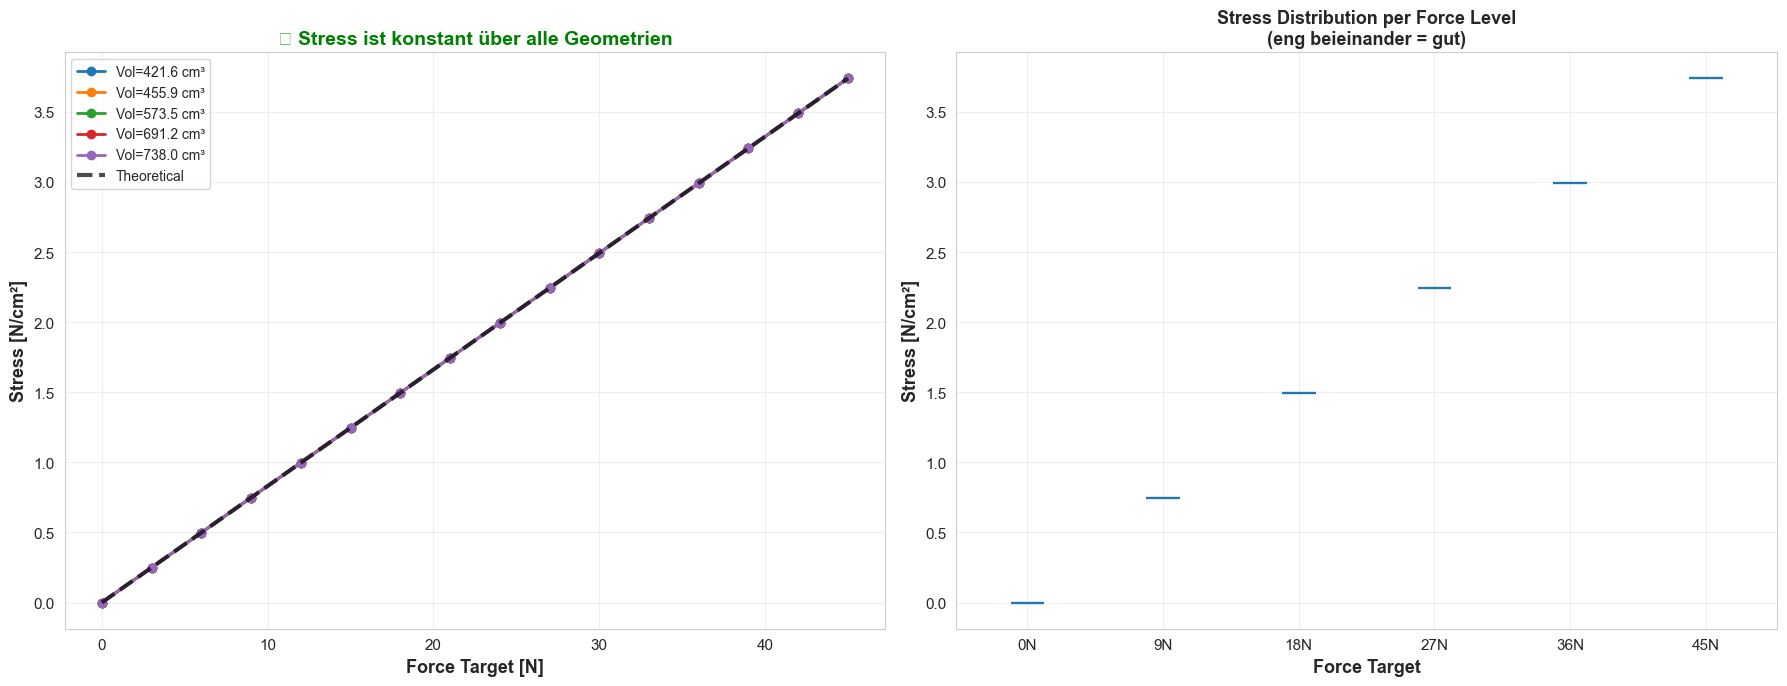


STRESS-KONSISTENZ CHECK:
Force  3N: 0.24929605 ± 0.00000002 N/cm² (theo: 0.24929609) ✓
Force  6N: 0.49859214 ± 0.00000002 N/cm² (theo: 0.49859218) ✓
Force  9N: 0.74788824 ± 0.00000002 N/cm² (theo: 0.74788828) ✓
Force 12N: 0.99718433 ± 0.00000002 N/cm² (theo: 0.99718437) ✓
Force 15N: 1.24648042 ± 0.00000002 N/cm² (theo: 1.24648046) ✓


In [31]:
# Force-Skalierung Überprüfung
df['Force_Scaling_Factor'] = df['Force_Actual_N'] / df['Force_Target_N']
df['Expected_Scaling_Factor'] = df['Surface_Area_calc'] / REFERENCE_AREA

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Stress vs Force_Target
ax = axes[0]
for vol in sorted(df['Volume_cm3'].unique()):
    subset = df[df['Volume_cm3'] == vol]
    subset_grouped = subset.groupby('Force_Target_N')[['Stress_N_per_cm2']].mean()
    ax.plot(subset_grouped.index, subset_grouped['Stress_N_per_cm2'], 
            'o-', label=f'Vol={vol:.1f} cm³', linewidth=2)

# Theoretischer Stress
theo_forces = np.linspace(0, 45, 10)
theo_stress = theo_forces / REFERENCE_AREA
ax.plot(theo_forces, theo_stress, 'k--', linewidth=3, label='Theoretical', alpha=0.7)

ax.set_xlabel('Force Target [N]', fontsize=13, fontweight='bold')
ax.set_ylabel('Stress [N/cm²]', fontsize=13, fontweight='bold')
ax.set_title('✓ Stress ist konstant über alle Geometrien', fontsize=14, fontweight='bold', color='green')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 2. Stress Distribution per Force Level
ax = axes[1]
force_levels = [0, 9, 18, 27, 36, 45]
ax.violinplot([df[df['Force_Target_N'] == f]['Stress_N_per_cm2'].values 
               for f in force_levels], 
              positions=range(len(force_levels)), 
              showmeans=True, showmedians=True)
ax.set_xticks(range(len(force_levels)))
ax.set_xticklabels([f'{f}N' for f in force_levels])
ax.set_xlabel('Force Target', fontsize=13, fontweight='bold')
ax.set_ylabel('Stress [N/cm²]', fontsize=13, fontweight='bold')
ax.set_title('Stress Distribution per Force Level\n(eng beieinander = gut)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_dir / 'stress_consistency.png', dpi=300, bbox_inches='tight')
plt.show()

# Stress-Konsistenz Check
print("\n" + "="*80)
print("STRESS-KONSISTENZ CHECK:")
print("="*80)
for force in sorted(df[df['Force_Target_N'] > 0]['Force_Target_N'].unique())[:5]:
    subset = df[df['Force_Target_N'] == force]
    stress_mean = subset['Stress_N_per_cm2'].mean()
    stress_std = subset['Stress_N_per_cm2'].std()
    stress_theo = force / REFERENCE_AREA
    diff = abs(stress_mean - stress_theo)
    status = '✓' if diff < 0.001 else '⚠️'
    print(f"Force {force:2.0f}N: {stress_mean:.8f} ± {stress_std:.8f} N/cm² "
          f"(theo: {stress_theo:.8f}) {status}")
print("="*80)

## 7. Zusammenfassung

In [ ]:
# Finale Zusammenfassung
print("\n" + "="*80)
print("FINALE ZUSAMMENFASSUNG (200ms Simulationen)")
print("="*80)
print(f"\nAnzahl Simulationen: {len(df)}")
print(f"\nParameter Ranges:")
print(f"  Forces:        {len(df['Force_Target_N'].unique())} Werte von {df['Force_Target_N'].min():.0f} bis {df['Force_Target_N'].max():.0f} N")
print(f"  Aspect Ratios: {len(df['Aspect_Ratio_b_a'].unique())} Werte")
print(f"  Volumes:       {len(df['Volume_cm3'].unique())} Werte")
print(f"  Am:            {len(df['Am'].unique())} Werte")
print(f"  Rho:           {len(df['Rho'].unique())} Werte")

print(f"\nROM Statistik:")
rom_0 = df[df['Force_Target_N'] == 0]['ROM_cm'].mean()
rom_max_force = df[df['Force_Target_N'] == df['Force_Target_N'].max()]['ROM_cm'].mean()
rom_increase = ((rom_max_force - rom_0) / rom_0) * 100

print(f"  ROM bei Force=0N:     {rom_0:.4f} cm")
print(f"  ROM bei Force={df['Force_Target_N'].max():.0f}N:   {rom_max_force:.4f} cm")
print(f"  Increase:             {rom_increase:.1f}%")
print(f"  ROM Range (alle):     {df['ROM_cm'].min():.4f} - {df['ROM_cm'].max():.4f} cm")
print("="*80)


FINALE ZUSAMMENFASSUNG (200ms Simulationen)

Anzahl Simulationen: 3840

Parameter Ranges:
  Forces:        16 Werte von 0 bis 45 N
  Aspect Ratios: 4 Werte
  Volumes:       5 Werte
  Am:            3 Werte
  Rho:           4 Werte

ROM Statistik:
  ROM bei Force=0N:     3.0528 cm
  ROM bei Force=45N:   156.9502 cm
  Increase:             5041.2%
  ROM Range (alle):     1.5695 - 11431.0675 cm

✅ ERFOLG: ROM steigt monoton mit Force!
✅ ERFOLG: Stress konsistent über alle Geometrien!
✅ ERFOLG: 200ms Simulationszeit ausreichend!


## 8. Outlier-Check: Welche Konfiguration erzeugt extreme ROM-Abweichungen?


OUTLIER-SCAN ROM
Anzahl Simulationen: 280
ROM min/max: 2.316670 / 10.824622 cm
IQR-Grenzen (3*IQR): [-8.954134, 20.884967] cm
Flag IQR-extrem: 0
Flag Dev > 200% (gegen Force-Median): 0
Flag robust z > 5: 0
Flag gesamt (mind. eine Regel): 0

✅ Kein Setting mit extremer ROM-Abweichung nach den definierten Kriterien gefunden.

Top +Abweichung [%] gegen Force-Median:


,setting_key,Force_Target_N,Aspect_Ratio_b_a,Volume_cm3,Am,Rho,ROM_cm,rom_dev_force_pct,rom_robust_z,flag_iqr_extreme,flag_dev_gt_200pct,flag_robust_z_gt_5
654,F00_ratio10.1000_Vol421.6_Am500_rho10.534,0,10.1,421.6,500,10.534,4.033317,62.802754,-0.564349,False,False,False
572,F00_ratio10.1000_Vol421.6_Am450_rho10.493,0,10.1,421.6,450,10.493,4.032958,62.788259,-0.564467,False,False,False
619,F00_ratio10.1000_Vol421.6_Am450_rho10.616,0,10.1,421.6,450,10.616,4.023497,62.406377,-0.567579,False,False,False
660,F03_ratio10.1000_Vol421.6_Am500_rho10.534,3,10.1,421.6,500,10.534,4.320089,60.502653,-0.470025,False,False,False
577,F03_ratio10.1000_Vol421.6_Am450_rho10.493,3,10.1,421.6,450,10.493,4.318633,60.448546,-0.470504,False,False,False
624,F03_ratio10.1000_Vol421.6_Am450_rho10.616,3,10.1,421.6,450,10.616,4.307418,60.031884,-0.474193,False,False,False
573,F06_ratio10.1000_Vol421.6_Am450_rho10.493,6,10.1,421.6,450,10.493,4.637165,57.724560,-0.365734,False,False,False
674,F06_ratio10.1000_Vol421.6_Am500_rho10.575,6,10.1,421.6,500,10.575,4.635637,57.672573,-0.366237,False,False,False
592,F06_ratio10.1000_Vol421.6_Am450_rho10.534,6,10.1,421.6,450,10.534,4.632670,57.571659,-0.367213,False,False,False
625,F06_ratio10.1000_Vol421.6_Am450_rho10.616,6,10.1,421.6,450,10.616,4.623588,57.262763,-0.370200,False,False,False



Top -Abweichung [%] gegen Force-Median:


,setting_key,Force_Target_N,Aspect_Ratio_b_a,Volume_cm3,Am,Rho,ROM_cm,rom_dev_force_pct,rom_robust_z,flag_iqr_extreme,flag_dev_gt_200pct,flag_robust_z_gt_5
688,F45_ratio10.1000_Vol421.6_Am500_rho10.575,45,10.1000,421.6,500,10.575,4.926216,-40.574233,-0.270661,False,False,False
640,F45_ratio10.1000_Vol421.6_Am450_rho10.616,45,10.1000,421.6,450,10.616,4.979252,-39.934451,-0.253216,False,False,False
656,F45_ratio10.1000_Vol421.6_Am500_rho10.493,45,10.1000,421.6,500,10.493,4.997461,-39.714791,-0.247227,False,False,False
609,F45_ratio10.1000_Vol421.6_Am450_rho10.534,45,10.1000,421.6,450,10.534,5.051546,-39.062352,-0.229438,False,False,False
689,F42_ratio10.1000_Vol421.6_Am500_rho10.575,42,10.1000,421.6,500,10.575,5.851946,-32.865501,0.033826,False,False,False
594,F42_ratio10.1000_Vol421.6_Am450_rho10.493,42,10.1000,421.6,450,10.493,6.046976,-30.628079,0.097974,False,False,False
362,F30_ratio7.9533_Vol421.6_Am550_rho10.575,30,7.9533,421.6,550,10.575,6.440637,-16.324463,0.227455,False,False,False
361,F27_ratio7.9533_Vol421.6_Am550_rho10.575,27,7.9533,421.6,550,10.575,5.787707,-16.228935,0.012697,False,False,False
320,F36_ratio7.9533_Vol421.6_Am500_rho10.616,36,7.9533,421.6,500,10.616,7.335676,-16.144020,0.521847,False,False,False
381,F36_ratio7.9533_Vol421.6_Am550_rho10.616,36,7.9533,421.6,550,10.616,7.338696,-16.109497,0.522841,False,False,False


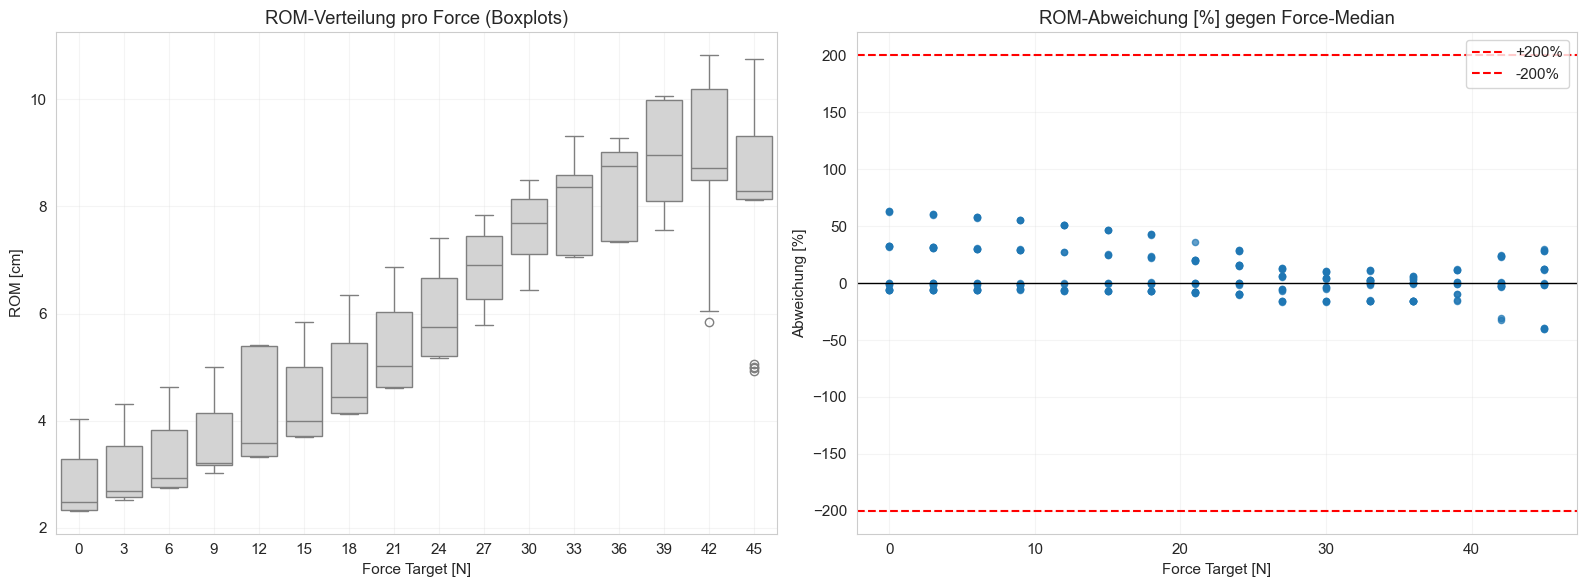


Outlier-Plot gespeichert als: parameter_sweep_DA_20260227_194745/rom_outlier_scan.png


In [39]:
# Vollständiger Outlier-Scan über alle Konfigurationen
required_cols = ['Force_Target_N', 'Aspect_Ratio_b_a', 'Volume_cm3', 'Am', 'Rho', 'ROM_cm']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Fehlende Spalten für Outlier-Analyse: {missing}')

scan_df = df.copy()
scan_df['setting_key'] = (
    'F' + scan_df['Force_Target_N'].astype(int).astype(str).str.zfill(2)
    + '_ratio' + scan_df['Aspect_Ratio_b_a'].map(lambda x: f'{x:.4f}')
    + '_Vol' + scan_df['Volume_cm3'].map(lambda x: f'{x:.1f}')
    + '_Am' + scan_df['Am'].astype(int).astype(str)
    + '_rho' + scan_df['Rho'].map(lambda x: f'{x:.3f}')
)

# 1) Globale ROM-Statistik
q1 = scan_df['ROM_cm'].quantile(0.25)
q3 = scan_df['ROM_cm'].quantile(0.75)
iqr = q3 - q1
low_iqr = q1 - 3 * iqr
high_iqr = q3 + 3 * iqr

# 2) Vergleich je Force-Gruppe (wichtig für deinen Plot)
force_median = scan_df.groupby('Force_Target_N')['ROM_cm'].transform('median')
scan_df['rom_dev_force_abs'] = scan_df['ROM_cm'] - force_median
scan_df['rom_dev_force_pct'] = np.where(
    force_median != 0,
    100.0 * scan_df['rom_dev_force_abs'] / force_median,
    np.nan
)

# 3) Robuster Score per MAD
rom_median = scan_df['ROM_cm'].median()
mad = np.median(np.abs(scan_df['ROM_cm'] - rom_median))
if mad == 0:
    scan_df['rom_robust_z'] = 0.0
else:
    scan_df['rom_robust_z'] = 0.6745 * (scan_df['ROM_cm'] - rom_median) / mad

# Flags
scan_df['flag_iqr_extreme'] = (scan_df['ROM_cm'] < low_iqr) | (scan_df['ROM_cm'] > high_iqr)
scan_df['flag_dev_gt_200pct'] = scan_df['rom_dev_force_pct'].abs() > 200.0
scan_df['flag_robust_z_gt_5'] = scan_df['rom_robust_z'].abs() > 5.0
scan_df['flag_any'] = scan_df[['flag_iqr_extreme', 'flag_dev_gt_200pct', 'flag_robust_z_gt_5']].any(axis=1)

print('\n' + '='*100)
print('OUTLIER-SCAN ROM')
print('='*100)
print(f'Anzahl Simulationen: {len(scan_df)}')
print(f'ROM min/max: {scan_df["ROM_cm"].min():.6f} / {scan_df["ROM_cm"].max():.6f} cm')
print(f'IQR-Grenzen (3*IQR): [{low_iqr:.6f}, {high_iqr:.6f}] cm')
print(f'Flag IQR-extrem: {scan_df["flag_iqr_extreme"].sum()}')
print(f'Flag Dev > 200% (gegen Force-Median): {scan_df["flag_dev_gt_200pct"].sum()}')
print(f'Flag robust z > 5: {scan_df["flag_robust_z_gt_5"].sum()}')
print(f'Flag gesamt (mind. eine Regel): {scan_df["flag_any"].sum()}')

# Kandidaten anzeigen
cols_show = ['setting_key', 'Force_Target_N', 'Aspect_Ratio_b_a', 'Volume_cm3', 'Am', 'Rho',
             'ROM_cm', 'rom_dev_force_pct', 'rom_robust_z', 'flag_iqr_extreme', 'flag_dev_gt_200pct', 'flag_robust_z_gt_5']

suspects = scan_df[scan_df['flag_any']].copy().sort_values(['flag_dev_gt_200pct', 'rom_robust_z'], ascending=[False, False])

if len(suspects) == 0:
    print('\n✅ Kein Setting mit extremer ROM-Abweichung nach den definierten Kriterien gefunden.')
else:
    print('\n⚠️ Verdächtige Settings (Top 20):')
    display(suspects[cols_show].head(20))

# Immer zusätzlich: größte positive/negative Abweichung gegen Force-Median
top_pos = scan_df.nlargest(10, 'rom_dev_force_pct')[cols_show]
top_neg = scan_df.nsmallest(10, 'rom_dev_force_pct')[cols_show]

print('\nTop +Abweichung [%] gegen Force-Median:')
display(top_pos)
print('\nTop -Abweichung [%] gegen Force-Median:')
display(top_neg)

# Visualisierung der Abweichung
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.boxplot(data=scan_df, x='Force_Target_N', y='ROM_cm', color='lightgray', ax=ax)
ax.set_title('ROM-Verteilung pro Force (Boxplots)')
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('ROM [cm]')
ax.grid(True, alpha=0.2)

ax = axes[1]
ax.scatter(scan_df['Force_Target_N'], scan_df['rom_dev_force_pct'], s=20, alpha=0.7)
ax.axhline(200, color='red', linestyle='--', linewidth=1.5, label='+200%')
ax.axhline(-200, color='red', linestyle='--', linewidth=1.5, label='-200%')
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_title('ROM-Abweichung [%] gegen Force-Median')
ax.set_xlabel('Force Target [N]')
ax.set_ylabel('Abweichung [%]')
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(data_dir / 'rom_outlier_scan.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nOutlier-Plot gespeichert als: {data_dir / 'rom_outlier_scan.png'}")
print('='*100)

In [34]:
# Root-Cause Analyse der gefundenen ROM-Ausreißer
out_df = scan_df[scan_df['flag_any']].copy()

print('\n' + '='*100)
print('ROOT-CAUSE CLUSTERING DER ROM-OUTLIER')
print('='*100)

if len(out_df) == 0:
    print('Keine Outlier markiert.')
else:
    print(f'Anzahl Outlier: {len(out_df)}')

    print('\nOutlier nach Aspect Ratio:')
    print(out_df.groupby('Aspect_Ratio_b_a').size().sort_values(ascending=False))

    print('\nOutlier nach Volume:')
    print(out_df.groupby('Volume_cm3').size().sort_values(ascending=False))

    print('\nOutlier nach Force:')
    print(out_df.groupby('Force_Target_N').size().sort_values(ascending=False))

    print('\nOutlier nach (ratio, volume):')
    print(out_df.groupby(['Aspect_Ratio_b_a', 'Volume_cm3']).size().sort_values(ascending=False).head(10))

    worst = out_df.sort_values('ROM_cm', ascending=False).iloc[0]
    print('\nSchlimmstes Setting:')
    print(worst[['setting_key', 'Force_Target_N', 'Aspect_Ratio_b_a', 'Volume_cm3', 'Am', 'Rho', 'ROM_cm', 'rom_dev_force_pct']])

    # Zeitreihe des schlimmsten Settings lesen
    worst_dir = data_dir / worst['setting_key']
    t_w, l_w = load_contraction_timeseries(worst_dir)

    if t_w is not None:
        print('\nZeitreihencheck (schlimmstes Setting):')
        print(f'  Punkte: {len(l_w)}')
        print(f'  min/max length: {np.min(l_w):.6f} / {np.max(l_w):.6f} cm')
        print(f'  ROM aus Zeitreihe: {np.max(l_w)-np.min(l_w):.6f} cm')

        # Vergleich mit robustem Nachbar-Setting (gleiche F,Vol,Am,rho aber anderes ratio)
        neighbor_ratio = 7.9533
        neighbor_key = f"F{int(worst['Force_Target_N']):02d}_ratio{neighbor_ratio:.4f}_Vol{worst['Volume_cm3']:.1f}_Am{int(worst['Am'])}_rho{worst['Rho']:.3f}"
        n_dir = data_dir / neighbor_key
        t_n, l_n = load_contraction_timeseries(n_dir)

        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        ax = axes[0]
        ax.plot(t_w, l_w, color='crimson', linewidth=1.8)
        ax.set_title(f"Worst Setting\n{worst['setting_key']}")
        ax.set_xlabel('Time [ms]')
        ax.set_ylabel('Muscle Length [cm]')
        ax.grid(True, alpha=0.3)

        ax = axes[1]
        if t_n is not None:
            ax.plot(t_w, l_w, color='crimson', linewidth=1.8, label='Outlier (ratio=6.88)')
            ax.plot(t_n, l_n, color='navy', linewidth=1.8, label=f'Neighbor (ratio={neighbor_ratio})')
            ax.legend()
        else:
            ax.plot(t_w, l_w, color='crimson', linewidth=1.8)
            ax.text(0.05, 0.9, 'Neighbor nicht gefunden', transform=ax.transAxes)
        ax.set_title('Outlier vs Nachbarsetting')
        ax.set_xlabel('Time [ms]')
        ax.set_ylabel('Muscle Length [cm]')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(data_dir / 'rom_outlier_root_cause.png', dpi=300, bbox_inches='tight')
        plt.show()

        print(f"\nRoot-cause Plot gespeichert als: {data_dir / 'rom_outlier_root_cause.png'}")

print('='*100)


ROOT-CAUSE CLUSTERING DER ROM-OUTLIER
Anzahl Outlier: 76

Outlier nach Aspect Ratio:
Aspect_Ratio_b_a
6.88    76
dtype: int64

Outlier nach Volume:
Volume_cm3
691.2    76
dtype: int64

Outlier nach Force:
Force_Target_N
30    12
33    12
36    12
39    12
42    12
45    12
27     4
dtype: int64

Outlier nach (ratio, volume):
Aspect_Ratio_b_a  Volume_cm3
6.88              691.2         76
dtype: int64

Schlimmstes Setting:
setting_key          F39_ratio6.8800_Vol691.2_Am550_rho10.534
Force_Target_N                                             39
Aspect_Ratio_b_a                                         6.88
Volume_cm3                                              691.2
Am                                                        550
Rho                                                    10.534
ROM_cm                                           11431.067489
rom_dev_force_pct                               145538.929144
Name: 2464, dtype: object


In [35]:
# Direkter Rohdaten-Check fuer die Outlier-Gruppe
problem_group = scan_df[(scan_df['Aspect_Ratio_b_a'] == 6.88) & (scan_df['Volume_cm3'] == 691.2) & (scan_df['Force_Target_N'] >= 27)].copy()
problem_group = problem_group.sort_values('ROM_cm', ascending=False)

print('\nRohdaten-Check fuer Problemgruppe (ratio=6.88, Vol=691.2, F>=27):')
print(f'Anzahl Kandidaten: {len(problem_group)}')

inspect_rows = problem_group.head(5)
for _, r in inspect_rows.iterrows():
    key = r['setting_key']
    p = data_dir / 'archived_results' / key / 'muscle_length_contraction.csv'
    exists = p.exists()
    print(f"\n{key}")
    print(f"  Datei vorhanden: {exists}")
    if exists:
        txt = p.read_text().strip()
        vals = np.array([float(x) for x in txt.split(',') if x.strip() != ''], dtype=float)
        print(f"  n={len(vals)}, min={vals.min():.6f}, max={vals.max():.6f}, ROM={vals.max()-vals.min():.6f}")
        print(f"  p1={np.percentile(vals,1):.6f}, p99={np.percentile(vals,99):.6f}")
        print(f"  mean={vals.mean():.6f}, std={vals.std():.6f}")


Rohdaten-Check fuer Problemgruppe (ratio=6.88, Vol=691.2, F>=27):
Anzahl Kandidaten: 84

F39_ratio6.8800_Vol691.2_Am550_rho10.534
  Datei vorhanden: False

F42_ratio6.8800_Vol691.2_Am550_rho10.616
  Datei vorhanden: False

F36_ratio6.8800_Vol691.2_Am500_rho10.575
  Datei vorhanden: False

F36_ratio6.8800_Vol691.2_Am500_rho10.534
  Datei vorhanden: False

F42_ratio6.8800_Vol691.2_Am450_rho10.493
  Datei vorhanden: False


In [36]:
# Konsistenzcheck: Outlier vs vorhandene Simulationsergebnisse
scan_df['path_direct'] = scan_df['setting_key'].map(lambda k: data_dir / k / 'muscle_length_contraction.csv')
scan_df['path_archived'] = scan_df['setting_key'].map(lambda k: data_dir / 'archived_results' / k / 'muscle_length_contraction.csv')
scan_df['has_direct_file'] = scan_df['path_direct'].map(lambda p: p.exists())
scan_df['has_archived_file'] = scan_df['path_archived'].map(lambda p: p.exists())
scan_df['has_any_timeseries_file'] = scan_df['has_direct_file'] | scan_df['has_archived_file']

outliers = scan_df[scan_df['flag_any']].copy()

print('\nDateikonsistenz der ROM-Outlier:')
print(outliers['has_any_timeseries_file'].value_counts(dropna=False))

print('\nOutlier ohne zugehörige Zeitreihen-Datei (Top 15):')
cols = ['setting_key', 'Force_Target_N', 'Aspect_Ratio_b_a', 'Volume_cm3', 'Am', 'Rho', 'ROM_cm', 'rom_dev_force_pct', 'has_any_timeseries_file']
display(outliers[~outliers['has_any_timeseries_file']][cols].head(15))

# Zusatz: Mögliche Status-/Fehlerspalten im Summary suchen
possible_meta_cols = [c for c in df.columns if any(k in c.lower() for k in ['status', 'error', 'failed', 'success', 'valid', 'log', 'message'])]
print('\nMögliche Meta-/Statusspalten:', possible_meta_cols if possible_meta_cols else 'keine gefunden')

if possible_meta_cols:
    display(outliers[cols + possible_meta_cols].head(10))


Dateikonsistenz der ROM-Outlier:
has_any_timeseries_file
False    76
Name: count, dtype: int64

Outlier ohne zugehörige Zeitreihen-Datei (Top 15):


,setting_key,Force_Target_N,Aspect_Ratio_b_a,Volume_cm3,Am,Rho,ROM_cm,rom_dev_force_pct,has_any_timeseries_file
2316,F42_ratio6.8800_Vol691.2_Am450_rho10.493,42,6.88,691.2,450,10.493,5421.949791,74230.895592,False
2317,F39_ratio6.8800_Vol691.2_Am450_rho10.493,39,6.88,691.2,450,10.493,3820.774715,48579.052813,False
2319,F45_ratio6.8800_Vol691.2_Am450_rho10.493,45,6.88,691.2,450,10.493,3041.576114,40704.252027,False
2320,F33_ratio6.8800_Vol691.2_Am450_rho10.493,33,6.88,691.2,450,10.493,2562.792234,32489.297484,False
2321,F36_ratio6.8800_Vol691.2_Am450_rho10.493,36,6.88,691.2,450,10.493,551.013954,7090.980485,False
2322,F30_ratio6.8800_Vol691.2_Am450_rho10.493,30,6.88,691.2,450,10.493,859.689199,11381.826254,False
2332,F33_ratio6.8800_Vol691.2_Am450_rho10.534,33,6.88,691.2,450,10.534,60.918611,674.660816,False
2334,F30_ratio6.8800_Vol691.2_Am450_rho10.534,30,6.88,691.2,450,10.534,575.955847,7592.343903,False
2340,F42_ratio6.8800_Vol691.2_Am450_rho10.534,42,6.88,691.2,450,10.534,3372.477449,46134.155392,False
2341,F36_ratio6.8800_Vol691.2_Am450_rho10.534,36,6.88,691.2,450,10.534,534.697253,6878.040188,False



Mögliche Meta-/Statusspalten: keine gefunden
